# 定義元素變異
表示法：定義每個企業創新策略元素為一個基因。  
初始群體生成：創建一個包含多個個體的初始群體，每個個體是一組隨機選擇的策略元素組合。  
適應度函數：設計一個適應度函數來評估每個個體的優良程度。可以根據一些具體指標（如市場反應、投資回報率等）來評估策略組合的優劣。  
選擇：根據適應度函數選擇一些優良個體進行交配和變異。  
交叉：對選擇的個體進行交叉操作，生成新的個體。  
變異：對一些個體進行變異操作，以引入多樣性。  
迭代：重複以上步驟多次，直到找到最優的策略組合。

使用期交所的歷史台指期資料  
存入的檔案日期當天的，漲跌是由前一天的新聞判斷  
這個方法只有判斷 yes no 沒有 unknown  

檔案說明：  
存在 out_element  


In [1]:
import os
import textwrap
import math
import pandas as pd
import numpy as np
from collections import Counter
from datetime import datetime
from dateutil.relativedelta import relativedelta
from IPython.display import display
from IPython.display import Markdown

from langchain_openai import ChatOpenAI

import google.generativeai as genai
from langchain.schema.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory

def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

# llm = ChatGoogleGenerativeAI(
#                 google_api_key = os.getenv('GEMINI_API_KEY'),
#                 model=model,
#                 temperature=temperature,
#                 top_p=top_p,
#                 seed=seed,
#                 safety_settings={
#                         HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
#                         HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
#                         HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
#                         HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
                
#             })

llm = ChatOpenAI(
  openai_api_key = os.getenv('OPENAI_API_KEY'),
  model='gpt-4o-mini',
  temperature=1,
)

# print(llm.invoke("hello world"))
# print(llm.model_name)
# print(llm.temperature)

# path_price = os.path.join(os.path.abspath(os.path.dirname(os.getcwd())), 'history_data', 'tw', 'stock_price', id + 'tech.csv')
# path_news_title = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + id + "news_title.json"
stock_id = '2330'
path_out = f"out_stock/GA/{stock_id}/"

/Users/yanyifu/Documents/_Coding/LLM Predict Stock/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 定義策略元素字典，每個元素對應一個代號
# elements = {
#     "E1": "企業創新策略：企業創新的核心主題，涵蓋所有驅動企業增長和競爭力提升的策略。",
#     "E2": "滿足客戶需求：企業創新的首要驅動力，能否滿足客戶需求直接影響創新成敗。",
#     "E3": "吸引投資者關注：投資者的關注和信心能為企業提供必要的資金和支持，是創新成功的重要標誌。",
#     "E4": "市場需求與趨勢：市場需求的變化和行業趨勢是影響企業股票表現的關鍵因素，企業需適應並預測市場變化。",
#     "E5": "財務表現：穩定且增長的收入、利潤和現金流是吸引投資者的主要因素，能增加投資者信心，推動股價上漲。",
#     "E6": "技術進步與研發投入：持續的技術創新和研發投入能提高企業競爭力和市場地位，促進企業長期增長。",
#     "E7": "經營效率：有效的經營管理能提高企業盈利能力，進而提升股票價值。",
#     "E8": "品牌聲譽與市場認可度：良好的品牌聲譽和市場認可度能增加企業產品的市場需求，促進銷售增長。",
#     "E9": "政策與法規支持：政府政策和法規對行業的支持或限制會直接影響企業的發展前景和市場表現。",
#     "E10": "競爭優勢與市場份額：企業在市場中的競爭優勢和市場份額的提升能增強其市場地位，吸引更多投資者。",
#     "E11": "全球化與國際市場拓展：進入國際市場並擴展全球業務能增加企業的市場規模和收入來源。",
#     "E12": "風險管理與應對能力：有效的風險管理策略和應對能力能降低企業運營風險，提高投資者信心。",
#     "E13": "人才管理與員工激勵：擁有高素質的人才和有效的激勵機制能提升企業創新能力和生產效率。",
#     "E14": "合作夥伴關係：與其他企業建立戰略合作夥伴關係能共享資源和技術，提升市場競爭力。",
#     "E15": "市場營銷與品牌推廣：有效的市場營銷和品牌推廣策略能提高企業知名度和市場需求。",
#     "E16": "客戶服務與滿意度：高品質的客戶服務和較高的客戶滿意度能提高客戶忠誠度和口碑。",
#     "E17": "供應鏈管理：高效的供應鏈管理能確保產品質量和交付效率，降低成本。",
#     "E18": "產品多樣化與創新：不斷推出創新產品和服務能滿足不同市場需求，提升企業競爭力。",
#     "E19": "環保與可持續發展：採用環保和可持續發展策略能提高企業形象，吸引關注可持續投資的投資者。",
#     "E20": "數位轉型與科技應用：積極進行數位轉型和應用新技術能提高運營效率和市場響應速度。",
#     "E21": "競爭對手分析與市場擴展：深入分析競爭對手的策略和行動，制定有效的市場擴展和新市場進入策略。",
#     "E22": "資本結構、財務穩定性與資金籌措：健康的資本結構和財務穩定性以及有效的資金籌措能增強企業的抗風險能力和持續發展能力。",
#     "E23": "客戶數據分析：利用大數據和數據分析技術深入了解客戶需求，提升產品和服務的針對性。",
#     "E24": "知識產權保護：有效保護企業的知識產權能防止競爭對手抄襲，提高創新成果的市場價值。",
#     "E25": "企業文化與價值觀：建立積極向上的企業文化和價值觀能吸引優秀人才，提升企業凝聚力和創新力。",
#     "E26": "股東回報與分紅政策：穩定的股東回報和合理的分紅政策能吸引長期投資者。",
#     "E27": "社會責任與公益活動：積極參與社會責任和公益活動能提升企業形象，獲得更多社會支持。",
#     "E28": "成本控制: 有效的成本控制能提高企業獲利能力。",
# }

elements = {
    "E1": "利潤增長: 企業的利潤增長可以反映出其盈利能力的提升，吸引更多投資者。",
    "E2": "股價波動率: 股價的波動幅度能夠顯示市場對企業的短期反應和投資風險。",
    "E3": "市場情緒指標: 反映市場投資者的情緒，包括樂觀或悲觀，影響股票的交易活動。",
    "E4": "每日交易量: 交易量反映市場中對該股票的需求，交易量變化會影響股價走勢。",
    "E5": "市場趨勢追蹤: 追踪市場的總體趨勢，幫助預測個股在市場中的表現。",
    "E6": "財報發佈: 公司定期公佈的財務報告可以反映出企業的經營狀況，對股價有顯著影響。",
    "E7": "技術圖表分析: 通過技術指標和圖表模式來分析股票的潛在走勢，協助做出投資決策。",
    "E8": "價格移動平均線: 平滑短期價格波動，幫助判斷股票的中長期趨勢。",
    "E9": "公司內部管理調整: 內部管理的調整會影響企業的運營效率和員工士氣。",
    "E10": "風險管理措施: 有效的風險管理措施能降低市場波動對公司經營的負面影響。",
    "E11": "外匯匯率波動: 外匯匯率變動對國際企業的財務表現和市場評估產生直接影響。",
    "E12": "競爭者動作: 競爭對手的市場策略或行為變化可能直接影響公司股價表現。",
    "E13": "投資者情緒調查: 反映投資者對市場或公司未來表現的預期，對股價有指引作用。",
    "E14": "技術創新: 新技術的研發和應用能為企業帶來競爭優勢，推動業務增長。",
    "E15": "公司新聞發布: 公司相關的正面或負面新聞會快速影響市場對其的預期和股價波動。",
    "E16": "業內消息與謠言: 業內消息或謠言可能會影響市場對企業的認知，進而影響股價。",
    "E17": "政府政策變動: 政府政策的改變會對企業的經營環境和利潤產生重大影響。",
    "E18": "國際經濟事件影響: 全球性經濟事件如貿易戰或金融危機，會影響國際企業的表現。",
    "E19": "資金流入與流出: 資金流動狀況反映了市場對該企業未來走勢的信心和預期。",
    "E20": "股東回報政策: 穩定的股東回報政策能增加投資者的持股意願，推動股價穩定上升。",
    "E21": "銷售數據公佈: 銷售數據能反映公司產品需求狀況，對未來收益具有預示作用。",
    "E22": "市場需求波動: 市場對公司產品或服務的需求波動會直接影響其業績和股價表現。",
    "E23": "成本控制措施: 良好的成本控制可以提升利潤率，從而對股價有積極影響。",
    "E24": "競爭對手行為分析: 競爭對手的產品定價、行銷策略等變動會改變公司競爭格局。",
    "E25": "客戶需求變化: 客戶需求的快速變化會對公司產品策略和市場反應產生影響。",
    "E26": "價格調整策略: 公司的價格調整策略會影響其產品市場定位，從而影響銷售和收益。",
    "E27": "預測性財務數據: 預期的財務數據公佈可能會影響市場預期和股票交易活動。",
    "E28": "新產品推出時間點: 新產品推出的時間和效果會影響市場對企業未來增長的信心。",
    "E29": "供應鏈中斷: 供應鏈中斷會影響公司的生產能力和產品交付，進而影響股價。",
    "E30": "產品質量問題: 產品質量問題會損害公司聲譽，影響市場對其產品需求和股價。",
    "E31": "市場推廣活動: 有效的市場推廣活動能提高產品知名度，促進銷售和利潤增長。",
    "E32": "研發投入變動: 研發投入的變動會影響公司未來創新能力和市場競爭力。",
    "E33": "股息分配調整: 股息政策的調整會影響投資者的投資決策和市場對公司前景的看法。",
    "E34": "市場份額增減: 市場份額的變化反映了企業在行業中的競爭力和未來增長潛力。",
    "E35": "投資者信心波動: 投資者對公司未來表現的信心波動會直接反映在股價的波動上。",
    "E36": "行業競爭格局變化: 行業內的競爭格局變化會影響企業的市場定位和盈利能力。",
    "E37": "財務風險評估: 企業財務狀況的風險評估會影響投資者的持股意願和公司股價。",
    "E38": "合作夥伴變動: 與合作夥伴的關係變化會影響公司的市場策略和業務發展。",
    "E39": "社交媒體熱點: 社交媒體上的話題熱度可能會影響市場對公司的認知和股價波動。",
    "E40": "品牌推廣活動: 品牌推廣能提升公司產品的市場認知度，促進銷售和股價表現。",
    "E41": "市場認可度變動: 市場對公司產品或品牌的認可度變動，會影響銷售和投資者信心。",
    "E42": "投資者期望管理: 企業對投資者期望的管理能夠影響市場對公司未來表現的評估。",
    "E43": "財務報表修正: 財務報表的修正可能反映出之前數據的誤差，影響市場信心。",
    "E44": "價格競爭策略: 價格競爭策略的調整會影響企業的市場份額和利潤空間。",
    "E45": "行業趨勢變化: 行業趨勢的變化會影響公司未來的戰略和市場定位。",
    "E46": "原材料成本波動: 原材料價格的波動會影響公司的生產成本和利潤率。",
    "E47": "國際市場需求變化: 國際市場的需求變化會影響企業的出口和總體收入。",
    "E48": "科技應用變更: 科技應用的變更會提升企業的生產效率和市場應對能力。",
}



# Access by index using list of keys
key_list = list(elements.keys())
value_list = list(elements.values())

In [3]:
# 權值股的表現往往會影響大盤的走勢，以下是台灣股市權值股的新聞標題：
# 『{text_news}』

# 如果有滿足以下的條件，則請只回答#yes 否則只回答#no 如果無法判斷則回答#unknown
# {prompt}

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no/#unknown
# 你的理由: 說明你的判斷理由

In [4]:
# 權值股的表現往往會影響大盤的走勢，以下是台灣股市權值股的新聞標題：
# 『{text_news}』

# 如果有滿足以下的條件，則請只回答#yes 否則只回答#no
# {prompt}

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no
# 你的理由: 說明你的判斷理由

In [5]:
# 透過前一天的新聞判斷今日的股市走勢
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

# def call_tech(d):
#     path_his_tech = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_tech.csv"
#     # 讀取CSV檔案
#     df = pd.read_csv(path_his_tech, encoding='utf-8')
#     df['日期'] = pd.to_datetime(df['日期'], format='%Y%m%d')
#     df = df[(d == df['日期'])]

#     # 計算5日均線
#     ma5 = "之上" if df['MA5'].values[0] < df["收盤指數"].values[0] else "之下"
#     ma10 = "之上" if df['MA10'].values[0] < df["收盤指數"].values[0] else "之下"
#     ma20 = "之上" if df['MA20'].values[0] < df["收盤指數"].values[0] else "之下"
#     ema12 = "之上" if df['EMA12'].values[0] < df["收盤指數"].values[0] else "之下"
#     ema26 = "之上" if df['EMA26'].values[0] < df["收盤指數"].values[0] else "之下"
#     dif_macd = round(df['DIF'].values[0] - df['MACD'].values[0],3) 

#     elements = [
#         # f"收盤後股價在5日均線{ma5},10日均線{ma10},20日均線{ma20}",
#         # f"RSI值為{round(df['RSI'].values[0], 3)}",
#         # f"MACD指標值, DIF-MACD值:{dif_macd}",
#         # f"KD值為,k:{round(df['K'].values[0],1)},d:{round(df['D'].values[0], 1)}",
#         f'開盤{df["開盤指數"].values[0]}，最高{df["最高指數"].values[0]}，最低{df["最低指數"].values[0]}，收盤{df["收盤指數"].values[0]}',
#         # f"收盤後股價在12日加權平均線{ema12},26日加權平均線{ema26}",
#     ]

#     prompt = ""
#     for i in range(len(elements)):
#         prompt += f"{str(i+1)} : {elements[i]}\n"
#     return prompt

def analyze_market(st, et, stock_id, prompt):
    # stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
    path_price_his = f"{os.path.dirname(os.path.abspath(os.getcwd()))}/history_data/tw/stock_price/{stock_id}twse.csv"

    # 讀取CSV檔案
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['Date']) & (df_price_his['Date'] <= et)]

    idx = 1
    batch_size = 300
    output_data = {}  # 使用字典來存儲每一天的輸出數據

    while idx < len(df_price_his):
        batch = []
        for i in range(batch_size):
            if idx + i >= len(df_price_his):
                break
            
            # 取得前一日日期和新聞標題
            news_date = df_price_his.iloc[idx + i]['Date'] - timedelta(days=1)
            text_news = ""

            path_news_file = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"
            with open(path_news_file, 'r', encoding='utf-8') as f:
                news_data = json.load(f)
                text_news = "權值股的熱門新聞標題"
                text_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
            
            # 取得前一個交易日的技術指標
            # last_date = df_price_his.iloc[idx + i - 1]['日期']
            # tech_prompt = call_tech(last_date)
            # 當日股價的技術指標如下：
# 『{tech_prompt}』

            # 設置初始消息列表，包括 SystemMessage 和第一個 HumanMessage
            messages = [
                ("system", "你是一個厲害的股市操盤手，專長是當日沖消"),
                ("human",
f"""
權值股的表現往往會影響大盤的走勢，以下是台灣股市權值股的新聞標題：
『{text_news}』

如果有滿足以下的條件，則請只回答#yes 否則只回答#no 如果無法判斷則回答#unknown
{prompt}

用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
判斷結果: #yes/#no/#unknown
你的理由: 說明你的判斷理由
""")
            ]
            batch.append(messages)

        res = llm.batch(batch)

        for i in range(len(res)):
            # 被預測的日期
            date_str = df_price_his.iloc[idx + i]['Date'].strftime('%Y%m%d')
            output_data[date_str] = {
                "token": res[i].usage_metadata,
                "raw_data": res[i].content,
            }

        # time.sleep(60)
        idx += batch_size

    # 將所有輸出數據寫入到同一個json檔案中
    data = {
        "model": llm.model_name,
        "temperature": llm.temperature,
        "prompt": prompt,
        "stock_id": stock_id,
        "output_data": output_data,
    }
    
    return data

In [6]:
def save_data(folder_path, data):
    count = 1
    while True:
        if os.path.exists(folder_path + str(count) + ".json"):
            count += 1
            continue
        else:
            out_file = folder_path + str(count) + ".json"
            break
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    print(f"已儲存至{out_file}")
    return out_file

評分

In [7]:
import pandas as pd
import json
import os

def eval(output_data, stock_id):
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    token_input = 0
    token_output = 0

    path_price_his = f"{os.path.dirname(os.path.abspath(os.getcwd()))}/history_data/tw/stock_price/{stock_id}twse.csv"
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')

    for date_str, result in output_data.items():
        token_input += result["token"]["input_tokens"]
        token_output += result["token"]["output_tokens"]
        sig_str = result["raw_data"].split("你的理由")[0]
        sig = 0

        if "unknown" in sig_str:
            sig = 0
        elif "yes" in sig_str:
            sig = 1
        elif "no" in sig_str:
            sig = -1
        else:
            sig = 0

        df_price = df_price_his[df_price_his['Date'] == pd.to_datetime(date_str, format='%Y%m%d')]

        if df_price.empty:
            continue

        rtn = (float(df_price.iloc[0]['Close']) - float(df_price.iloc[0]['Open']))  / float(df_price.iloc[0]['Open']) 

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'avail_count': tp + fp + tn + fn,
        'ask_count': len(output_data),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
        'token_input': token_input,
        'token_output': token_output,
    }

    return result

# Training
遺傳演算法

In [8]:
import json
import random
from datetime import datetime

individual_score = {}
ask_count = 0
start_day = datetime(2023, 7, 1)
end_day = datetime(2024, 3, 30)
out_folder = f"{path_out}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}/"
state_file= out_folder + '/state.json'
results_file= out_folder + '/generation_results.json'
print("Start, ask_count:", ask_count, "individual_score:", individual_score, "第一次跑的話請確認state是空的")

Start, ask_count: 0 individual_score: {} 第一次跑的話請確認state是空的


In [9]:
# 儲存-----------------------------------------
# 儲存狀態
def save_state(filename, state, message):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    print("Save state", message, state)
    with open(filename, 'w') as f:
        json.dump(state, f)

# 載入狀態
def load_state(filename):
    try:
        with open(filename, 'r') as f:
            content = f.read().strip()
            if not content:
                return None
            return json.loads(content)
    except FileNotFoundError:
        return None

# 儲存每一代的結果
def save_generation_results(filename, generation, best_individual, best_fitness):
    result = {
        "generation": generation,
        "best_individual": best_individual,
        "best_fitness": best_fitness
    }
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'a') as f:
        f.write(json.dumps(result) + '\n')

# 遺傳演算法-----------------------------------------
# 初始群體生成
# Define the function to generate a population
def generate_population(size, num_elements):
    population = []
    
    for _ in range(size):
        # Generate an individual with binary encoding (0 or 1)
        individual = [random.randint(0, 1) for _ in range(num_elements)]
        population.append(individual)
    
    return population

# 適應度函數
def fitness(individual):
    global ask_count
    if str(individual) in individual_score:
        return individual_score[str(individual)]
    
    # 評分方法
    print("Fitness", individual)

    prompt = ""
    for i in range(len(individual)):
        if individual[i] == 1:
            prompt += f"{str(i+1)} : {value_list[i]}\n"

    scores = []
    for i in range(1):
        dic_data = analyze_market(start_day, end_day, stock_id, prompt)
        dic_data['individual'] = individual
        dic_data['generation'] = current_generation
        result = eval(dic_data["output_data"], stock_id)
        dic_data['result'] = result
        outpath = save_data(out_folder, dic_data)
        if result['avail_count'] > 40:
            scores.append(result['accuracy'])
        else:
            scores.append(0.5)
        ask_count += result['ask_count']
    score = sum(scores) / len(scores)

    individual_score[str(individual)] = score

    # 儲存狀態
    state = load_state(state_file)
    if state:
        current_pop = state['population']
    save_state(state_file, {'generation': current_generation, 'population': current_pop, 'individual_score': individual_score}, "fitness")
    score = 0
    return score

# 選擇
def selection(population):
    population.sort(key=lambda ind: fitness(ind), reverse=True)
    return population[:int(len(population)/2)]

# 交叉
def crossover(parent1, parent2, crossover_rate=0.7):
    if random.random() <= crossover_rate:
        idx = random.randint(1, len(parent1) - 1)
        child1 = parent1[:idx] + parent2[idx:]
        child2 = parent2[:idx] + parent1[idx:]
    else:
        # 如果不進行交叉，則直接保留父母作為子代
        child1, child2 = parent1, parent2
    return child1, child2

# 變異
def mutate(individual, mutation_rate=0.005):
    if random.random() < mutation_rate:
        idx = random.randint(0, len(individual)-1)
        individual[idx] = random.randint(0, 1)
    return individual

# 主程式-----------------------------------------
def genetic_algorithm(elements, population_size=20, generations=70):
    global individual_score, current_generation, current_population
    
    state = load_state(state_file)
    if state:
        current_population = state['population']
        start_generation = state['generation']
        individual_score = state['individual_score']

        if len(current_population) == 0:
            current_population = generate_population(population_size, len(elements))
    else:
        current_population = generate_population(population_size, len(elements))
        start_generation = 0
    
    # 儲存狀態
    save_state(state_file, {'generation': start_generation, 'population': current_population, 'individual_score': individual_score}, "init")   
    

    for current_generation in range(start_generation, generations):
        print(f"Generation {current_generation+1}")
        # print("current_population", current_population)
        print("selection")
        selected = selection(current_population)
        children = []
        print("crossover")
        while len(children) < population_size:
            parent1, parent2 = random.sample(selected, 2)
            child1, child2 = crossover(parent1, parent2)
            children.append(mutate(child1, 0.05))
            children.append(mutate(child2, 0.05))
        current_population = children
        best_individual = max(current_population, key=lambda ind: fitness(ind))
        best_fitness = fitness(best_individual)
        print(f"Best fitness = {best_fitness}")
        print(f"Best individual: {best_individual}")

        # 儲存狀態
        save_state(state_file, {'generation': current_generation+1, 'population': current_population, 'individual_score': individual_score}, "every generation")
        # 儲存每一代的結果
        save_generation_results(results_file, current_generation + 1, best_individual, best_fitness)
        print()
        
        # 假設某個機制觸發暫停
        if ask_count >= 100000:
            print("Paused")
            break

    return best_individual

# 執行
best_elements = genetic_algorithm(elements)
print()
print(f"Best elements: {best_elements}")
print(individual_score)

Save state init {'generation': 37, 'population': [[1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0

# Testing

In [12]:
individual = [1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0]
start_day = datetime(2024, 4, 1)
end_day = datetime(2024, 7, 31)

# 構建prompt
prompt = ""
for i in range(len(individual)):
    if individual[i] == 1:
        prompt += f"{str(i+1)} : {value_list[i]}\n"

# 分析市場
dic_data = analyze_market(start_day, end_day, stock_id, prompt)
result = eval(dic_data["output_data"], stock_id)
dic_data['individual'] = individual
dic_data['result'] = result

save_data(f"{out_folder}test{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}", dic_data)
print(result)

已儲存至out_stock/GA/2330//20230701_20240330/test20240401_202407311.json
{'tp': 37, 'fp': 25, 'tn': 5, 'fn': 3, 'avail_count': 70, 'ask_count': 81, 'accuracy': 0.6, 'precision': 0.5967741935483871, 'recall': 0.925, 'ev': 0.004421468951692459, 'precision_ev': 0.004317041968840385, 'token_input': 98814, 'token_output': 10657}


# DEMO

## 結果整理

In [59]:
import json

def print_out(data, state_str):
        output_data = data["output_data"]
        # Get the list of keys
        keys = list(output_data.keys())
        result = data["result"]

        # Get the first and last keys
        first_key = keys[0]
        last_key = keys[-1]

        print(f"{state_str} {first_key}～{last_key}")

        print(f'''tp:{result["tp"]}, fp:{result["fp"]}, tn:{result["tn"]}, fn:{result["fn"]}, Available ask:[{result["avail_count"]}/{result["ask_count"]}],
Accuracy : {round(result["accuracy"],3) }, Expected Value : {round(result["ev"], 7)},
Precision : {round(result["precision"],5)}, Precision Expected Value : {round(result["precision_ev"], 7)},
Recall : {round(result["recall"],5)}''')  

individual = [1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1]
out_folder = f"{path_out}/0701_0330_ynu_newele2/"
for i in range(1000):
    file_path = out_folder + str(i+1) + ".json" 
    if os.path.exists(file_path):
        with open(file_path, "r", encoding='utf-8') as f:
            data = json.load(f)
            if data["individual"] == individual:
                # print(f"第{i+1}筆資料")
                # result = data["result"]
                print_out(data, "Train")
                break
    else:
        break

print("")
for i in range(1):
    with open(out_folder + "test20240401_20240731" + str(i+1) + ".json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        # output_data = data["result"]
        # result = eval(output_data)
        print_out(data, "Test")


Train 20230704～20240329
tp:70, fp:35, tn:0, fn:0, Available ask:[105/181],
Accuracy : 0.667, Expected Value : 0.001211,
Precision : 0.66667, Precision Expected Value : 0.001211,
Recall : 1.0

Test 20240402～20240731
tp:40, fp:21, tn:0, fn:0, Available ask:[61/81],
Accuracy : 0.656, Expected Value : 0.0016379,
Precision : 0.65574, Precision Expected Value : 0.0016379,
Recall : 1.0


## 作圖
使用 Best so far

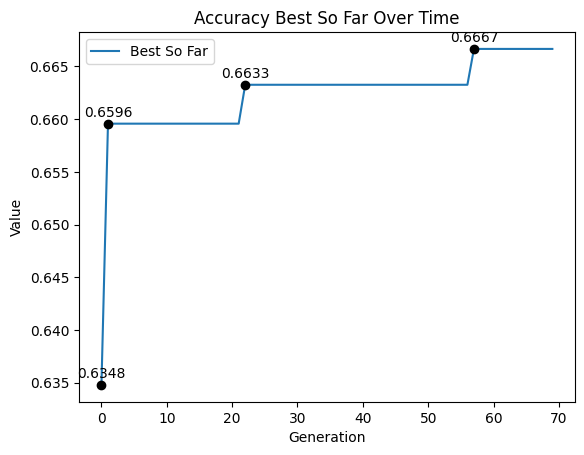

In [55]:
import json
import matplotlib.pyplot as plt

accs = []
evs = []
best_so_far = []  # 用來儲存每個世代中目前最好的值

# 設定要顯示的最大代數
max_generations = 70
out_folder = f"{path_out}/0701_0330_ynu_newele2/"

with open(f"{out_folder}generation_results.json", 'r') as f:
    content = f.readlines()
    current_best = float('-inf')  # 初始化為最小值
    for i, line in enumerate(content):
        if i >= max_generations:  # 超過最大代數後停止
            break
        result = json.loads(line)
        acc = result['best_fitness']
        accs.append(acc)
        
        # 計算best so far
        if acc > current_best:
            current_best = acc
        best_so_far.append(current_best)

# 繪圖
plt.plot(best_so_far, label='Best So Far')

# 標註數值變化的點並圈起來
for i in range(0, len(best_so_far)):
    if best_so_far[i] != best_so_far[i-1]:  # 只有變化點才標註
        plt.scatter(i, best_so_far[i], color='black', zorder=5)  # 圈出變化點
        plt.annotate(f'{best_so_far[i]:.4f}', (i, best_so_far[i]), textcoords="offset points", xytext=(0, 5), ha='center')

plt.title('Accuracy Best So Far Over Time')  # 添加標題
plt.xlabel('Generation')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()

plt.show()


## 計算使用的費用

In [144]:
import json

input_price = 0.075
output_price = 0.3

input_token = 0
output_token = 0
for i in range(121):
    with open(f"out_GA_twii/0701_03303/{i+1}.json", 'r') as f:
        data = json.load(f)
        output_data = data["output_data"]

        for date_str, result in output_data.items():
            input_token += result["token"]["input_tokens"]
            output_token += result["token"]["output_tokens"]
        # print(input_token, output_token)

print(f'token: input {input_token}, output {output_token}')
usd = (input_token/1000000)*input_price + (output_token/1000000)*output_price
print(f'預估費用 {usd} USD, {usd*32.6} TWD')

token: input 13008837, output 3458561
預估費用 2.013231075 USD, 65.631333045 TWD


## 比較

In [60]:
individual = [1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1]
prompt = ""
for i in range(len(individual)):
    if individual[i] == 1:
        prompt += f"{str(i+1)} : {value_list[i]}\n"
print(prompt)

# ele = ["E4", "E15", "E17", "E24", "E25"]
# prompt = ""
# for e in ele:
#     prompt += f"{e} : {elements[e]}\n"
# print(prompt)

1 : 利潤增長: 企業的利潤增長可以反映出其盈利能力的提升，吸引更多投資者。
2 : 股價波動率: 股價的波動幅度能夠顯示市場對企業的短期反應和投資風險。
6 : 財報發佈: 公司定期公佈的財務報告可以反映出企業的經營狀況，對股價有顯著影響。
7 : 技術圖表分析: 通過技術指標和圖表模式來分析股票的潛在走勢，協助做出投資決策。
9 : 公司內部管理調整: 內部管理的調整會影響企業的運營效率和員工士氣。
16 : 業內消息與謠言: 業內消息或謠言可能會影響市場對企業的認知，進而影響股價。
17 : 政府政策變動: 政府政策的改變會對企業的經營環境和利潤產生重大影響。
18 : 國際經濟事件影響: 全球性經濟事件如貿易戰或金融危機，會影響國際企業的表現。
19 : 資金流入與流出: 資金流動狀況反映了市場對該企業未來走勢的信心和預期。
23 : 成本控制措施: 良好的成本控制可以提升利潤率，從而對股價有積極影響。
24 : 競爭對手行為分析: 競爭對手的產品定價、行銷策略等變動會改變公司競爭格局。
25 : 客戶需求變化: 客戶需求的快速變化會對公司產品策略和市場反應產生影響。
26 : 價格調整策略: 公司的價格調整策略會影響其產品市場定位，從而影響銷售和收益。
28 : 新產品推出時間點: 新產品推出的時間和效果會影響市場對企業未來增長的信心。
31 : 市場推廣活動: 有效的市場推廣活動能提高產品知名度，促進銷售和利潤增長。
34 : 市場份額增減: 市場份額的變化反映了企業在行業中的競爭力和未來增長潛力。
36 : 行業競爭格局變化: 行業內的競爭格局變化會影響企業的市場定位和盈利能力。
37 : 財務風險評估: 企業財務狀況的風險評估會影響投資者的持股意願和公司股價。
39 : 社交媒體熱點: 社交媒體上的話題熱度可能會影響市場對公司的認知和股價波動。
40 : 品牌推廣活動: 品牌推廣能提升公司產品的市場認知度，促進銷售和股價表現。
41 : 市場認可度變動: 市場對公司產品或品牌的認可度變動，會影響銷售和投資者信心。
42 : 投資者期望管理: 企業對投資者期望的管理能夠影響市場對公司未來表現的評估。
44 : 價格競爭策略: 價格競爭策略的調整會影響企業的市場份額和利潤空間。
45 : 行業趨勢變化: 行業趨勢的變化會影響公司未來的戰略和市場定位。


In [33]:
import json

out_folder = f"{path_out}0701_0330_ynu_15pro/"
def print_out(data, state_str):
        output_data = data["output_data"]
        # Get the list of keys
        keys = list(output_data.keys())
        result = data["result"]

        # Get the first and last keys
        first_key = keys[0]
        last_key = keys[-1]

        print(f"{state_str} {first_key}～{last_key}")

        print(f'''tp:{result["tp"]}, fp:{result["fp"]}, tn:{result["tn"]}, fn:{result["fn"]}, Available ask:[{result["avail_count"]}/{result["ask_count"]}],
Accuracy : {round(result["accuracy"],3) }, Expected Value : {round(result["ev"], 7)},
Precision : {round(result["precision"],5)}, Precision Expected Value : {round(result["precision_ev"], 7)},
Recall : {round(result["recall"],5)}''')  

for i in range(83):
    with open(f"{out_folder}/{i+1}.json", 'r') as f:
        data = json.load(f)
        result = data["result"]
        if result['precision'] > 0.7:
            print(f"第{i+1}筆資料")
            print(f"訓練時的Precision:  {result['precision']}")
            print()
            # print(data['individual'])
            with open(f"{out_folder}/test_precision{i+1}.json", 'r') as f:
                out_data = json.load(f)
                res = out_data["result"]
                print_out(out_data, "測試")
                print("_"*50)


第16筆資料
訓練時的Precision:  0.7333333333333333

測試 20240402～20240731
tp:2, fp:4, tn:2, fn:2, Available ask:[10/81],
Accuracy : 0.4, Expected Value : 0.0033702,
Precision : 0.33333, Precision Expected Value : 0.0027902,
Recall : 0.5
__________________________________________________
第38筆資料
訓練時的Precision:  0.875

測試 20240402～20240731
tp:6, fp:1, tn:6, fn:7, Available ask:[20/81],
Accuracy : 0.6, Expected Value : 0.0030898,
Precision : 0.85714, Precision Expected Value : 0.0042249,
Recall : 0.46154
__________________________________________________
第62筆資料
訓練時的Precision:  0.7419354838709677

測試 20240402～20240731
tp:5, fp:4, tn:6, fn:6, Available ask:[21/81],
Accuracy : 0.524, Expected Value : 0.0011062,
Precision : 0.55556, Precision Expected Value : 0.0017478,
Recall : 0.45455
__________________________________________________
第67筆資料
訓練時的Precision:  0.7073170731707317

測試 20240402～20240731
tp:6, fp:8, tn:10, fn:16, Available ask:[40/81],
Accuracy : 0.4, Expected Value : -0.0010226,
Precision :

In [20]:
individual = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0]

start_day = datetime(2024, 4, 1)
end_day = datetime(2024, 7, 31)

# 構建prompt
prompt = ""
for i in range(len(individual)):
    if individual[i] == 1:
        prompt += f"{str(i+1)} : {value_list[i]}\n"

# 分析市場
dic_data = analyze_market(start_day, end_day, prompt)
result = eval(dic_data["output_data"])
dic_data['individual'] = individual
dic_data['result'] = result

save_data(f"{out_folder}test_precision16", dic_data)
print(result)

已儲存至out_twii/GA/0701_0330_ynu_15pro/test_precision1620240401_202407314.json
{'tp': 6, 'fp': 8, 'tn': 10, 'fn': 16, 'avail_count': 40, 'ask_count': 81, 'accuracy': 0.4, 'precision': 0.42857142857142855, 'recall': 0.2727272727272727, 'ev': -0.001022597041533973, 'precision_ev': -2.68395535186392e-05, 'token_input': 68894, 'token_output': 6107}


# 長線判斷
